# Plasmadiagnostik mit Langmuir-Sonden

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.optimize import least_squares
import os

In [3]:
def logline_res(coeff, x, y):
    a = coeff
    return np.log(y) - (np.power(x, a))

def logline(coeff, x):
    a = coeff
    return x**a

def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new = [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    return x_new, der

## Bestimmen des Plasmapotentials für alle (Sonden-) Kennlinien

Mögliche Methoden zur Bestimmung:
 1. Wendepunkt der Kennlinie: Maximum von $\frac{\mathrm{d}I_e(U)}{\mathrm{d}U}$
 2. Schnittpunkt der Geraden im $\ln (I_e)$ gegen $U$ plot

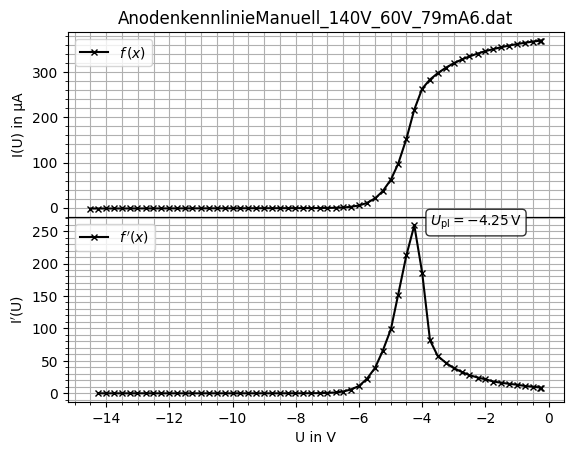

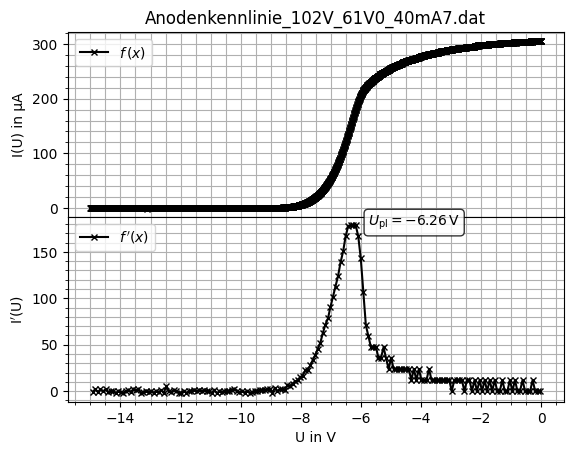

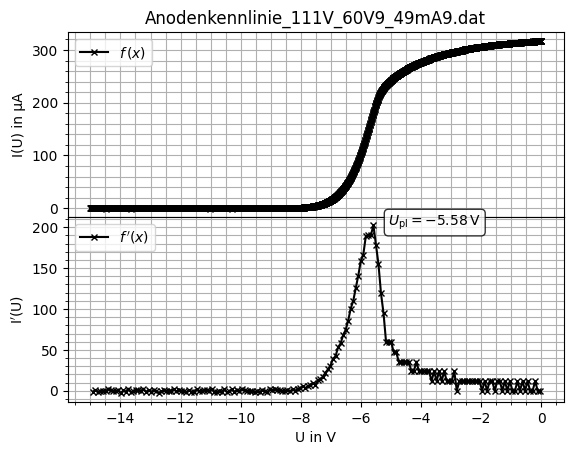

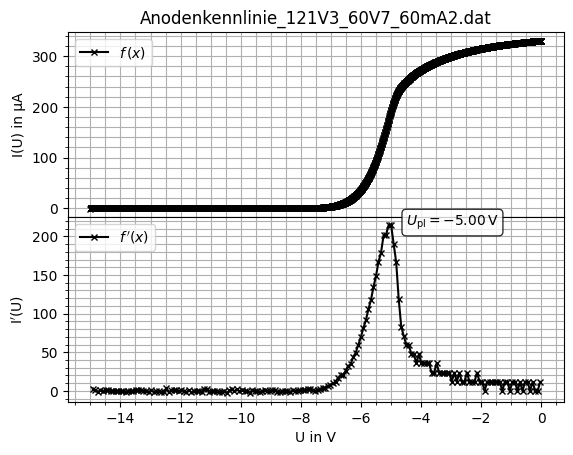

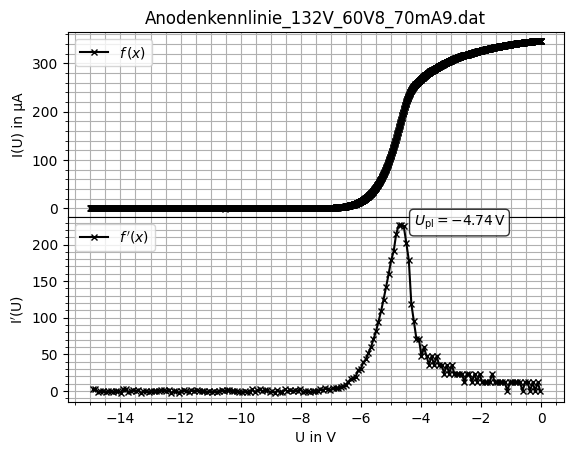

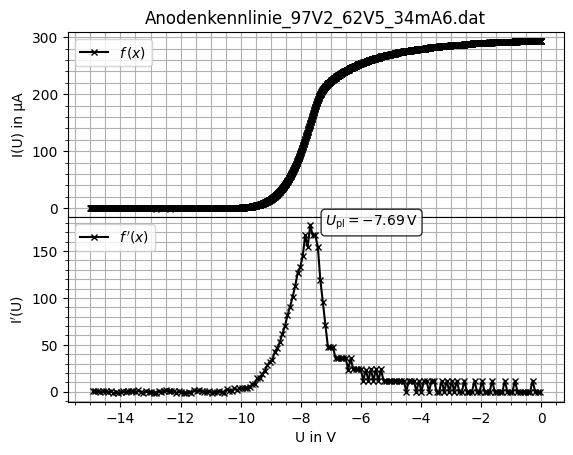

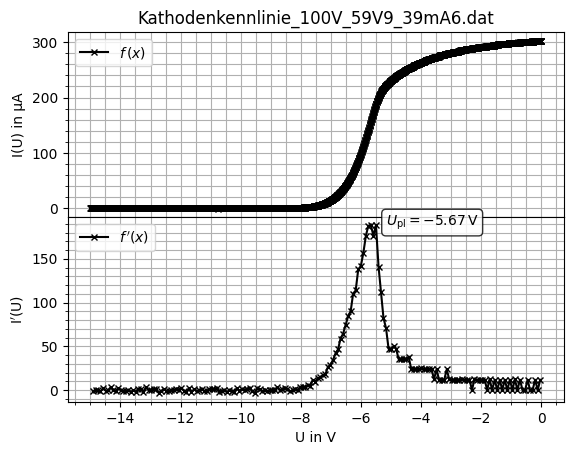

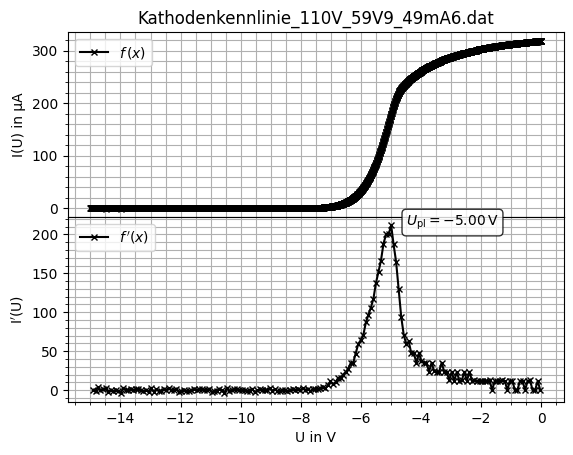

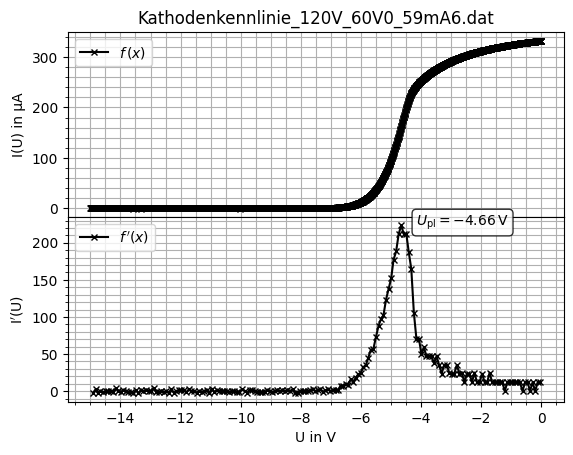

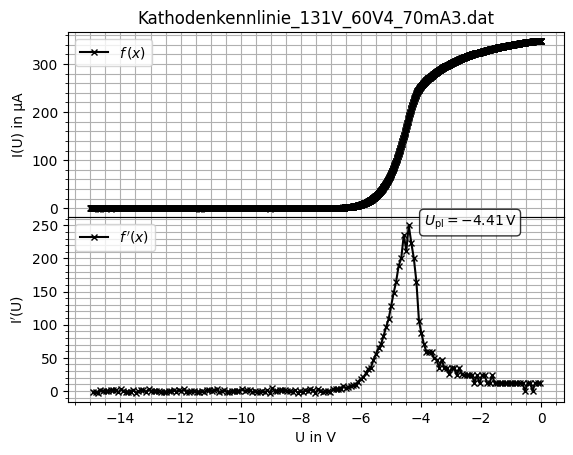

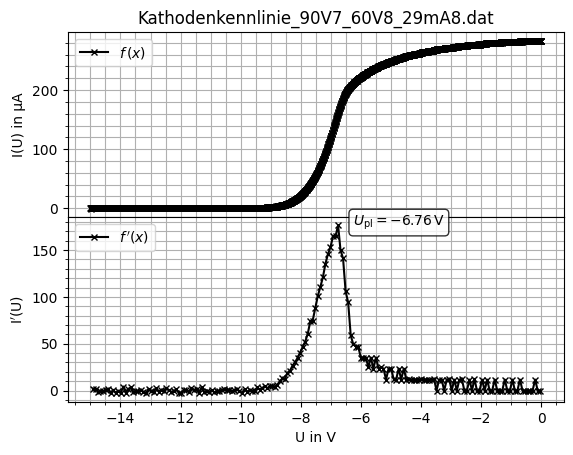

In [31]:
# Methode 1

for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Ableiten der Kennlinie funktioniert für die automatischen nur mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU = U
            dIdU = np.insert(np.diff(I)/np.diff(U), 0, np.nan)
        else:
            dU, dIdU = derive(U, I, step=14)
        imaxI = np.argmax(dIdU[1:])+1
        Upl = dU[imaxI]
        # plotten
        fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}) #layout='constrained')
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax2.plot(dU, dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
        ax2.set_xlabel('U in V')
        ax2.set_ylabel(r"I$'$(U)")
        ax1.set_ylabel('I(U) in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax2.legend(loc=2)
        ax2.grid(which='both')
        ax1.minorticks_on()
        ax2.minorticks_on()
        ax2.text(Upl+0.5, dIdU[imaxI], r'$U_\mathrm{pl}= %4.2f \,$V' %Upl, fontsize=10, bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})
        # optional speichern
        figname = file.split('.')[0]
        plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}.png')
        plt.show()

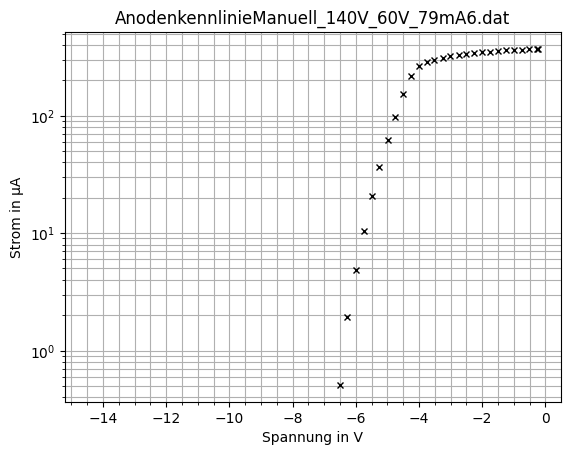

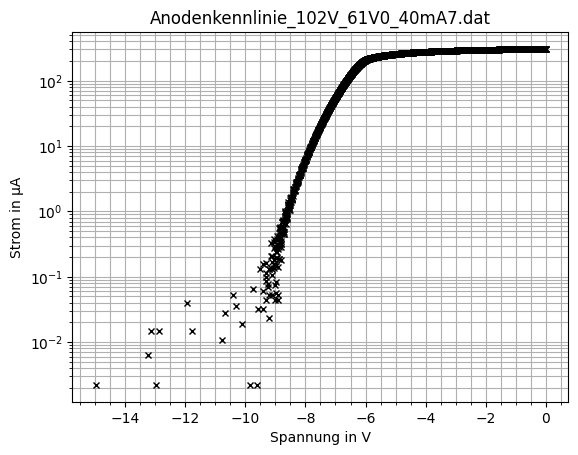

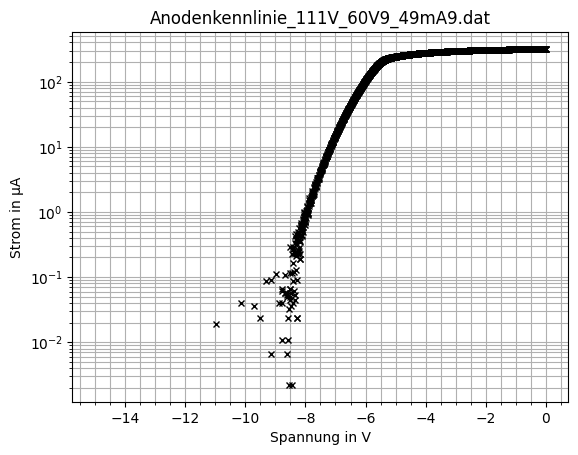

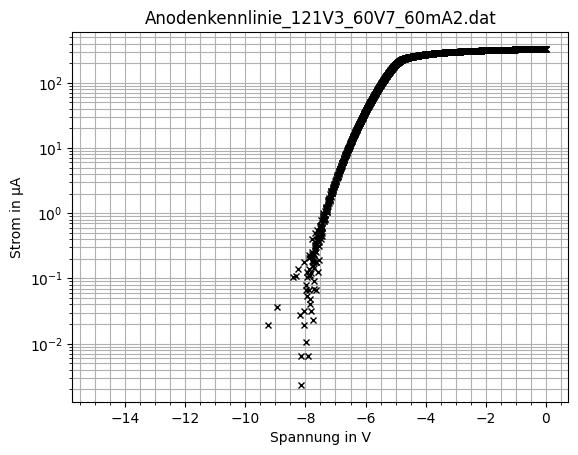

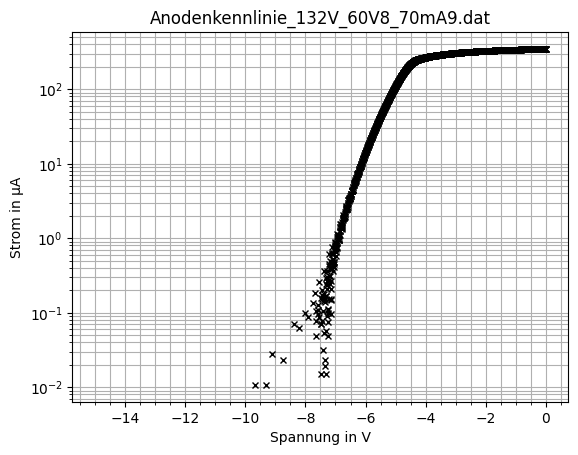

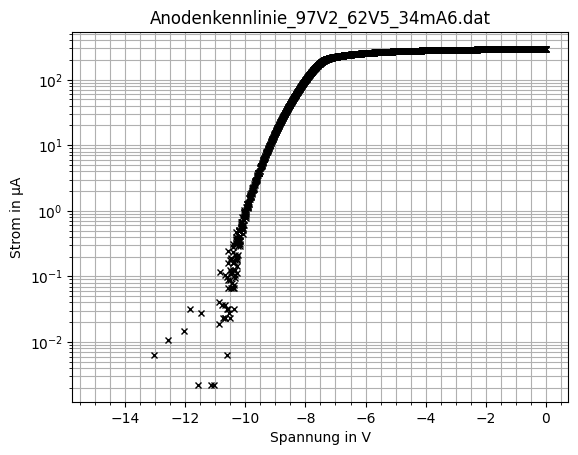

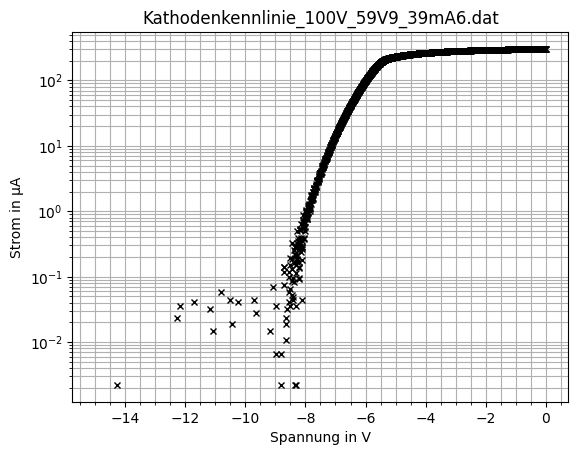

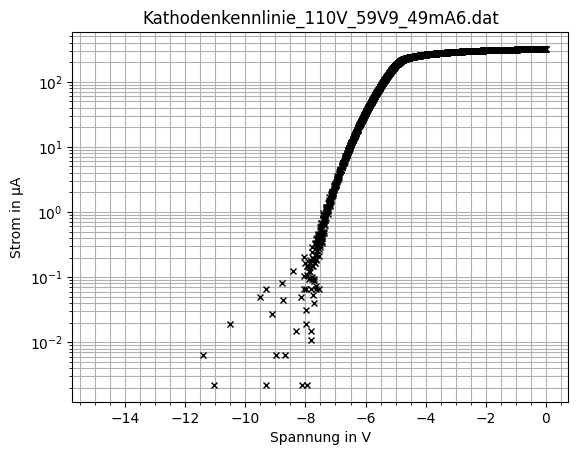

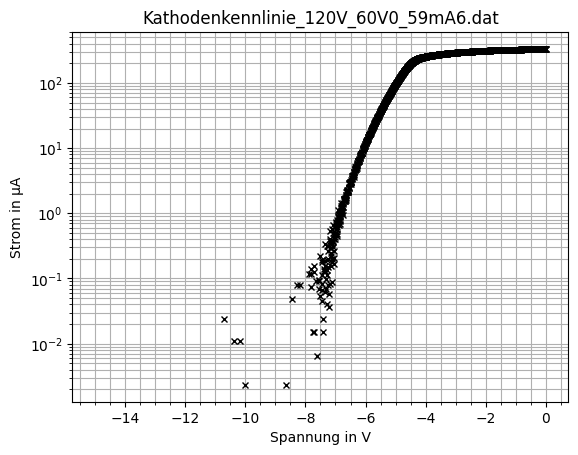

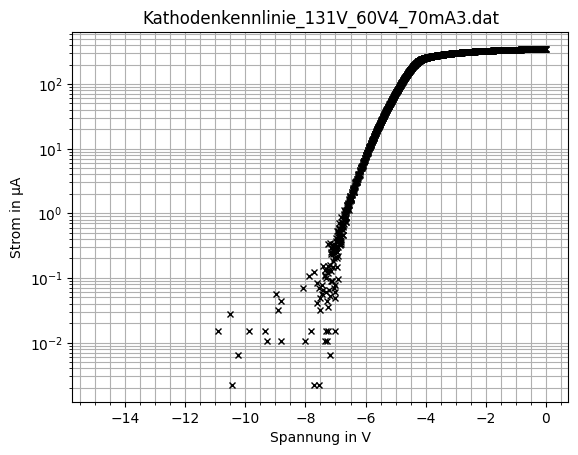

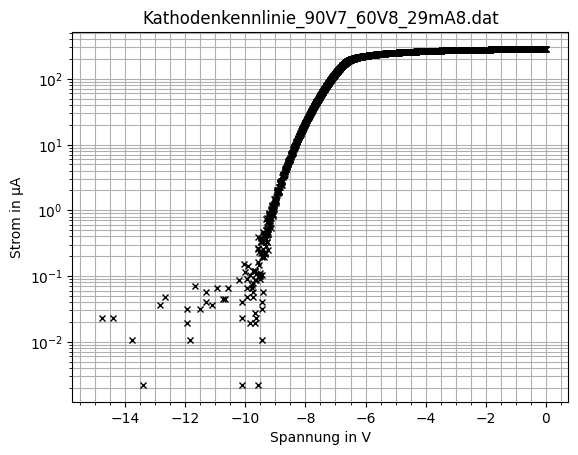

In [ ]:
# Methode 2


for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax = plt.subplots()
        ax.plot(U, I, 'xk', ms=4)
        ax.set_xlabel('Spannung in V')
        ax.set_ylabel('Strom in µA')
        ax.set_title(file)
        ax.set_yscale('log')
        ax.minorticks_on()
        plt.grid(which = 'both')
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_logplot.png')
        plt.show()

## Bestimmen des Floating-Potential und Elektronentemperatur
Floating-Potential ist der Nulldurchgang $I(U_\mathrm{float})=0$.  
Für den Elektronstrom im Elektronenanlaufbereich gilt: $$I_\mathrm{e}(U)=-\frac{1}{4}en_eA\sqrt{\frac{8k_BT_e}{\pi m_e}}\exp\left(\frac{e(U-U_{pl})}{k_BT_e} \right).$$

Dies lässt sich umformen zu $$\ln\left(\frac{I_e(U)}{1\,mA}\right)\propto\frac{eU}{k_BT_e}.$$
Aus der Steigung im halblogarithmisch geplotteten Elektronenanlaufbereich lässt sich also die Elektronentemperatur bestimmen. Dies sei Methode 1.

Methode 2 ist eine weitere Gleichung $$k_BT_e=\frac{e}{\ln\sqrt{\frac{\exp 1}{2\pi}\frac{m_i}{m_e}}}(U_{pl}-U_{float}).$$

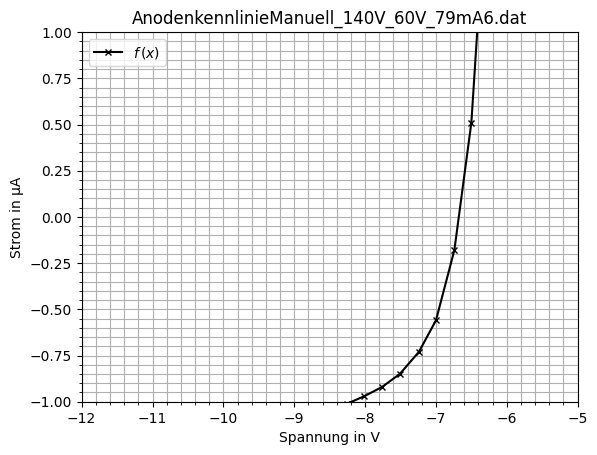

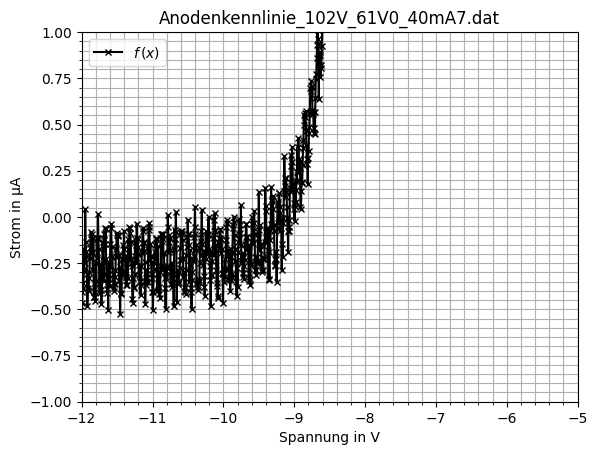

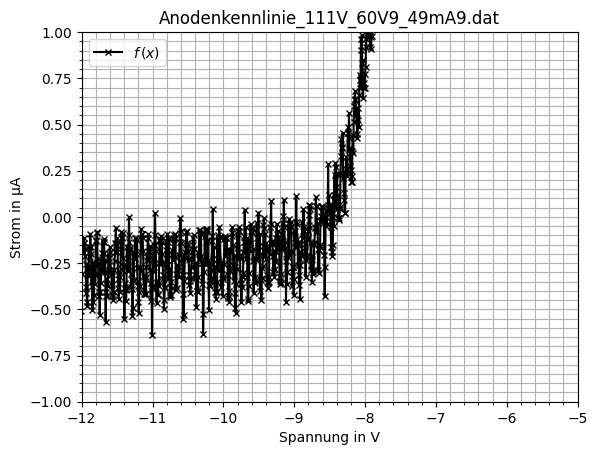

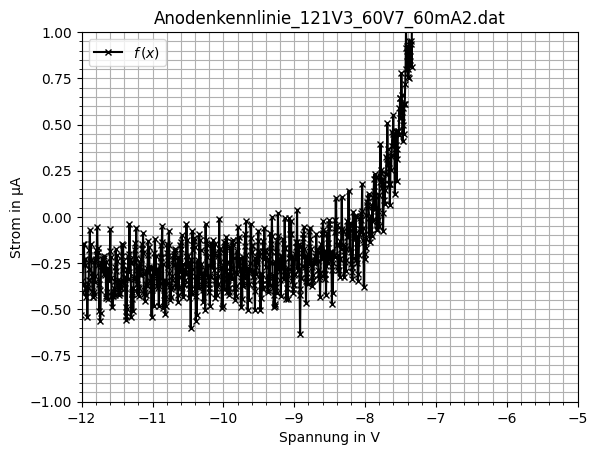

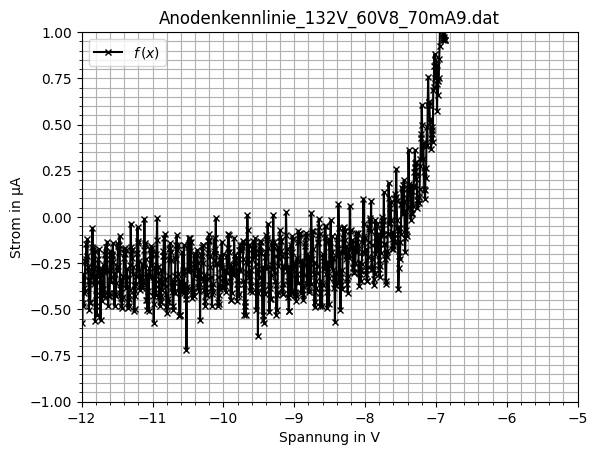

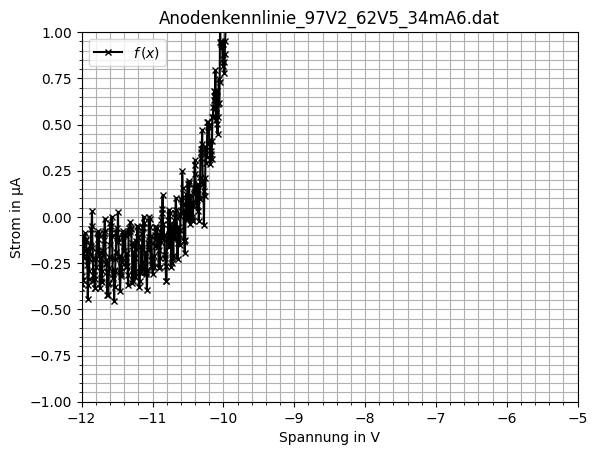

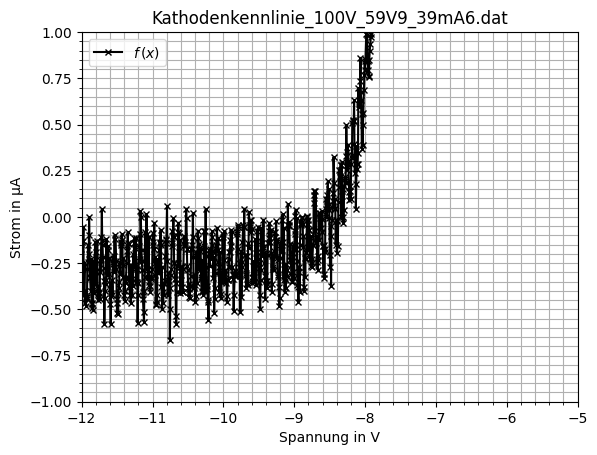

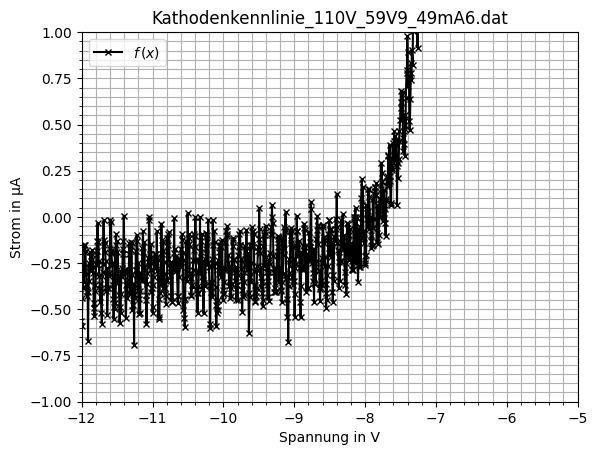

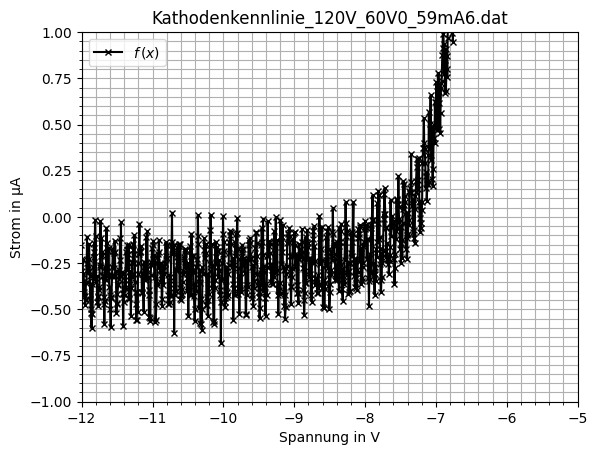

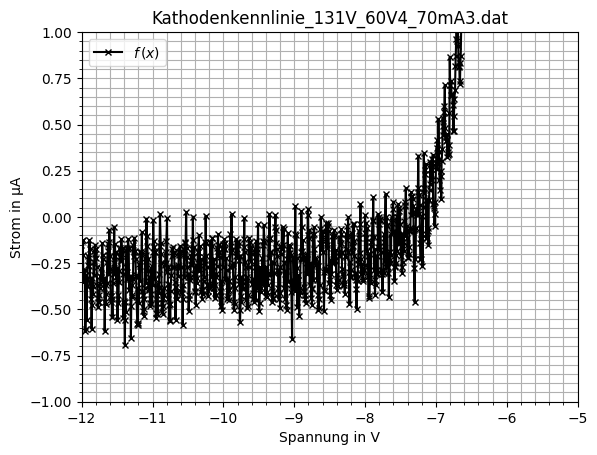

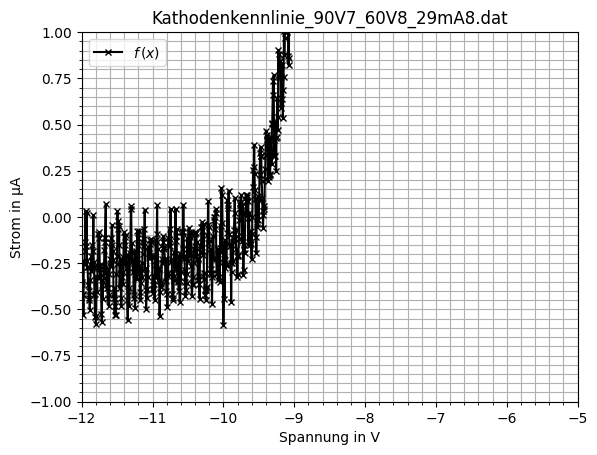

In [ ]:
# Floating Potential
for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # plotten
        fig, ax1 = plt.subplots()
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax1.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax1.grid(which='both')
        ax1.minorticks_on()
        ax1.set_ylim(-1, 1) # reinzoomen um Nulldurchgang abzulesen
        ax1.set_xlim(-12,-5)
        # optional speichern
        figname = file.split('.')[0]
        #plt.savefig(f'../Messdaten/17112025_Langmuirsonden/Bilder/{figname}_zoom_Nulldurchgang.png')
        plt.show()

In [ ]:
# Nulldurchgang dict
Ufl = {'140V' : -6.7, # manuelle Kennlinie
       '102V' : -9.2, # Anodenkennlinien
       '111V' : -9.5,
       '121V3': -7.8,
       '132V' : -7.5,
       '97V2' : -10.5,
       '90V7' : -9.6, # Kathodenkennlinien
       '100V' : -8.5,
       '110V' : -7.9,
       '120V' : -7.5,
       '131V' : -7.4
      } # in V

In [38]:
# Methode 1 Steigungsdreieck in halblog plot ablesen
Steigung = {'140V' : 264.66666667, # manuelle Kennlinie
            '102V' : 79.984, # Anodenkennlinien
            '111V' : 91.92,
            '121V3': 199.75,
            '132V' : 164.7,
            '97V2' : 114.27428571,
            '90V7' : 64.425, # Kathodenkennlinien
            '100V' : 119.92,
            '110V' : 124.75,
            '120V' : 74.875,
            '131V' : 99.85
            } # in µA/V

Te = const.e/np.array(list(Steigung.values()), dtype=float)/const.k
print(f'Elektronentemperatur: {Te.mean()} K')

Elektronentemperatur: 107.85461333136658 K
